In [1]:
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

from sklearn import linear_model
import scipy.stats as stats

from sklearn.metrics import roc_curve, roc_auc_score


sns.set_theme()

In [2]:
loan_data_inputs_train = pd.read_csv("../data/processed/loan_data_inputs_train.csv", index_col = 0)
loan_data_targets_train = pd.read_csv("../data/processed/loan_data_targets_train.csv", index_col = 0)
loan_data_inputs_test = pd.read_csv("../data/processed/loan_data_inputs_test.csv", index_col=0)
loan_data_targets_test = pd.read_csv("../data/processed/loan_data_targets_test.csv", index_col = 0)


In [3]:
loan_data_inputs_train.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,dti:21.7-22.4,dti:22.4-35,dti:>35,mths_since_last_record:Missing,mths_since_last_record:0-2,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>86
367333,367333,19156341,21359049,18450,18450,18450.0,36 months,7.12,570.70,A,...,0,0,0,1,0,0,0,0,0,0
434838,434838,12457093,14469207,29000,29000,29000.0,36 months,14.64,1000.19,C,...,0,1,0,1,0,0,0,0,0,0
231154,231154,37711505,40484499,11200,11200,11200.0,36 months,11.44,369.02,B,...,0,1,0,1,0,0,0,0,0,0
156660,156660,3667567,4630849,10625,10625,10625.0,36 months,21.00,400.30,E,...,0,0,0,1,0,0,0,0,0,0
87459,87459,7062702,8724284,13200,13200,13200.0,60 months,17.76,333.48,D,...,0,0,0,1,0,0,0,0,0,0


In [4]:
loan_data_targets_train.head()

,good_bad
367333,1
434838,1
231154,1
156660,1
87459,1


In [5]:
loan_data_inputs_train.shape

(349713, 324)

In [6]:
loan_data_targets_train.shape

(349713, 1)

In [7]:
loan_data_inputs_test.shape

(116572, 324)

In [8]:
loan_data_targets_test.shape

(116572, 1)

In [9]:
# Here we select a limited set of input variables in a new dataframe.
inputs_train_with_ref_cat = loan_data_inputs_train.loc[: , ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'home_ownership:OWN',
'home_ownership:MORTGAGE',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'addr_state:NM_VA',
'addr_state:NY',
'addr_state:OK_TN_MO_LA_MD_NC',
'addr_state:CA',
'addr_state:UT_KY_AZ_NJ',
'addr_state:AR_MI_PA_OH_MN',
'addr_state:RI_MA_DE_SD_IN',
'addr_state:GA_WA_OR',
'addr_state:WI_MT',
'addr_state:TX',
'addr_state:IL_CT',
'addr_state:KS_SC_CO_VT_AK_MS',
'addr_state:WV_NH_WY_DC_ME_ID',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'purpose:credit_card',
'purpose:debt_consolidation',
'purpose:oth__med__vacation',
'purpose:major_purch__car__home_impr',
'initial_list_status:f',
'initial_list_status:w',
'term:36',
'term:60',
'emp_length:0',
'emp_length:1',
'emp_length:2-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'mths_since_issue_d:<38',
'mths_since_issue_d:38-39',
'mths_since_issue_d:40-41',
'mths_since_issue_d:42-48',
'mths_since_issue_d:49-52',
'mths_since_issue_d:53-64',
'mths_since_issue_d:65-84',
'mths_since_issue_d:>84',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'mths_since_earliest_cr_line:141-164',
'mths_since_earliest_cr_line:165-247',
'mths_since_earliest_cr_line:248-270',
'mths_since_earliest_cr_line:271-352',
'mths_since_earliest_cr_line:>352',
'delinq_2yrs:0',
'delinq_2yrs:1-3',
'delinq_2yrs:>=4',
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',
'open_acc:0',
'open_acc:1-3',
'open_acc:4-12',
'open_acc:13-17',
'open_acc:18-22',
'open_acc:23-25',
'open_acc:26-30',
'open_acc:>=31',
'pub_rec:0-2',
'pub_rec:3-4',
'pub_rec:>=5',
'total_acc:<=27',
'total_acc:28-51',
'total_acc:>=52',
'acc_now_delinq:0',
'acc_now_delinq:>=1',
'total_rev_hi_lim:<=5K',
'total_rev_hi_lim:5K-10K',
'total_rev_hi_lim:10K-20K',
'total_rev_hi_lim:20K-30K',
'total_rev_hi_lim:30K-40K',
'total_rev_hi_lim:40K-55K',
'total_rev_hi_lim:55K-95K',
'total_rev_hi_lim:>95K',
'annual_inc:<20K',
'annual_inc:20K-30K',
'annual_inc:30K-40K',
'annual_inc:40K-50K',
'annual_inc:50K-60K',
'annual_inc:60K-70K',
'annual_inc:70K-80K',
'annual_inc:80K-90K',
'annual_inc:90K-100K',
'annual_inc:100K-120K',
'annual_inc:120K-140K',
'annual_inc:>140K',
'dti:<=1.4',
'dti:1.4-3.5',
'dti:3.5-7.7',
'dti:7.7-10.5',
'dti:10.5-16.1',
'dti:16.1-20.3',
'dti:20.3-21.7',
'dti:21.7-22.4',
'dti:22.4-35',
'dti:>35',
'mths_since_last_delinq:Missing',
'mths_since_last_delinq:0-3',
'mths_since_last_delinq:4-30',
'mths_since_last_delinq:31-56',
'mths_since_last_delinq:>=57',
'mths_since_last_record:Missing',
'mths_since_last_record:0-2',
'mths_since_last_record:3-20',
'mths_since_last_record:21-31',
'mths_since_last_record:32-80',
'mths_since_last_record:81-86',
'mths_since_last_record:>86',
]]

In [10]:
# Here we store the names of the reference category dummy variables in a list.
ref_categories = ['grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'initial_list_status:f',
'term:60',
'emp_length:0',
'mths_since_issue_d:>84',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'delinq_2yrs:>=4',
'inq_last_6mths:>6',
'open_acc:0',
'pub_rec:0-2',
'total_acc:<=27',
'acc_now_delinq:0',
'total_rev_hi_lim:<=5K',
'annual_inc:<20K',
'dti:>35',
'mths_since_last_delinq:0-3',
'mths_since_last_record:0-2']

In [11]:
inputs_train = inputs_train_with_ref_cat.drop(ref_categories, axis=1)

In [12]:
inputs_train.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,...,mths_since_last_delinq:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>86
367333,True,False,False,False,False,False,True,False,0,False,...,1,0,0,0,1,0,0,0,0,0
434838,False,False,True,False,False,False,False,True,0,False,...,0,1,0,0,1,0,0,0,0,0
231154,False,True,False,False,False,False,False,False,0,False,...,0,1,0,0,1,0,0,0,0,0
156660,False,False,False,False,True,False,False,False,0,False,...,1,0,0,0,1,0,0,0,0,0
87459,False,False,False,True,False,False,False,True,0,False,...,0,0,0,1,1,0,0,0,0,0


### Pd Model Estimation ###

In [13]:
reg = LogisticRegression()

In [14]:
reg.fit(inputs_train, loan_data_targets_train.values)

/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/senayberhe/Desktop/credit_risk_mode

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
reg.intercept_

array([-0.50937591])

In [16]:
reg.coef_

array([[ 0.94575858,  0.71616982,  0.53645019,  0.37571866,  0.26000422,
         0.12270853,  0.09972714,  0.10751921,  0.07475757,  0.05938021,
         0.09218138,  0.10253181,  0.10855224,  0.16174186,  0.11640692,
         0.20973242,  0.2269085 ,  0.26133233,  0.29241108,  0.36809917,
         0.43829915,  0.0900427 , -0.00667701,  0.26888215,  0.14829003,
         0.16028547,  0.22706465,  0.0550466 ,  0.07605547,  0.10781922,
         0.13650456,  0.09463043,  0.07159777,  0.1277203 ,  1.15969011,
         0.93733549,  0.84988876,  0.65688992,  0.48930675,  0.25214063,
        -0.01095072,  1.03656846,  0.69679188,  0.41513344,  0.1860494 ,
         0.09007863,  0.05872152,  0.09104804,  0.14031005,  0.14879871,
        -0.10427378, -0.11523455,  0.30240688,  0.1567487 , -0.04248477,
         0.00573818, -0.05060351, -0.08693752, -0.08475512, -0.07958608,
        -0.05731408, -0.08282019, -0.00819922,  0.03328175, -0.02433538,
         0.0143549 ,  0.15772035,  0.0269425 ,  0.0

In [17]:
feature_name = inputs_train.columns.values

In [18]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-0.509376
1,grade:A,0.945759
2,grade:B,0.716170
3,grade:C,0.536450
4,grade:D,0.375719
...,...,...
100,mths_since_last_record:3-20,0.204499
101,mths_since_last_record:21-31,0.177044
102,mths_since_last_record:32-80,0.338203
103,mths_since_last_record:81-86,0.021778


In [19]:
class LogisticRegression_with_p_values:
    def __init__(self, *args, **kwargs):
        self.model = linear_model.LogisticRegression(*args, **kwargs)

    def fit(self, X, y):
        # FIX: convert to float64 — pd.cut factor/categorical columns cause dtype('O')
        X = np.array(X, dtype=float)
        self.model.fit(X, y)
        denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(X))))
        denom = np.tile(denom, (X.shape[1], 1)).T
        F_ij = np.dot((X / denom).T, X)
        Cramer_Rao = np.linalg.inv(F_ij)
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        z_scores = self.model.coef_[0] / sigma_estimates
        p_values = [stats.norm.sf(abs(x)) * 2 for x in z_scores]
        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        self.p_values = p_values

In [20]:
reg = LogisticRegression_with_p_values()

In [21]:
reg.fit(inputs_train, loan_data_targets_train)

/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/senayberhe/Desktop/credit_risk_mode

In [22]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-0.509376
1,grade:A,0.945759
2,grade:B,0.716170
3,grade:C,0.536450
4,grade:D,0.375719
...,...,...
100,mths_since_last_record:3-20,0.204499
101,mths_since_last_record:21-31,0.177044
102,mths_since_last_record:32-80,0.338203
103,mths_since_last_record:81-86,0.021778


In [23]:
p_values = reg.p_values

In [24]:
p_values = np.append(np.nan, np.array(p_values))

In [25]:
summary_table['p_values'] = p_values

In [26]:
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-0.509376,NaN
1,grade:A,0.945759,1.967571e-23
2,grade:B,0.716170,2.946161e-29
3,grade:C,0.536450,1.403390e-19
4,grade:D,0.375719,2.713094e-11
...,...,...,...
100,mths_since_last_record:3-20,0.204499,1.206186e-01
101,mths_since_last_record:21-31,0.177044,1.522582e-01
102,mths_since_last_record:32-80,0.338203,4.962217e-04
103,mths_since_last_record:81-86,0.021778,8.475012e-01


In [27]:
# We are going to remove some features, the coefficients for all or almost all of the dummy variables for which,
# are not tatistically significant.

# We do that by specifying another list of dummy variables as reference categories, and a list of variables to remove.
# Then, we are going to drop the two datasets from the original list of dummy variables.

# Variables
inputs_train_with_ref_cat = loan_data_inputs_train.loc[: , ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'home_ownership:OWN',
'home_ownership:MORTGAGE',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'addr_state:NM_VA',
'addr_state:NY',
'addr_state:OK_TN_MO_LA_MD_NC',
'addr_state:CA',
'addr_state:UT_KY_AZ_NJ',
'addr_state:AR_MI_PA_OH_MN',
'addr_state:RI_MA_DE_SD_IN',
'addr_state:GA_WA_OR',
'addr_state:WI_MT',
'addr_state:TX',
'addr_state:IL_CT',
'addr_state:KS_SC_CO_VT_AK_MS',
'addr_state:WV_NH_WY_DC_ME_ID',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'purpose:credit_card',
'purpose:debt_consolidation',
'purpose:oth__med__vacation',
'purpose:major_purch__car__home_impr',
'initial_list_status:f',
'initial_list_status:w',
'term:36',
'term:60',
'emp_length:0',
'emp_length:1',
'emp_length:2-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'mths_since_issue_d:<38',
'mths_since_issue_d:38-39',
'mths_since_issue_d:40-41',
'mths_since_issue_d:42-48',
'mths_since_issue_d:49-52',
'mths_since_issue_d:53-64',
'mths_since_issue_d:65-84',
'mths_since_issue_d:>84',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'mths_since_earliest_cr_line:141-164',
'mths_since_earliest_cr_line:165-247',
'mths_since_earliest_cr_line:248-270',
'mths_since_earliest_cr_line:271-352',
'mths_since_earliest_cr_line:>352',
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',
'acc_now_delinq:0',
'acc_now_delinq:>=1',
'annual_inc:<20K',
'annual_inc:20K-30K',
'annual_inc:30K-40K',
'annual_inc:40K-50K',
'annual_inc:50K-60K',
'annual_inc:60K-70K',
'annual_inc:70K-80K',
'annual_inc:80K-90K',
'annual_inc:90K-100K',
'annual_inc:100K-120K',
'annual_inc:120K-140K',
'annual_inc:>140K',
'dti:<=1.4',
'dti:1.4-3.5',
'dti:3.5-7.7',
'dti:7.7-10.5',
'dti:10.5-16.1',
'dti:16.1-20.3',
'dti:20.3-21.7',
'dti:21.7-22.4',
'dti:22.4-35',
'dti:>35',
'mths_since_last_delinq:Missing',
'mths_since_last_delinq:0-3',
'mths_since_last_delinq:4-30',
'mths_since_last_delinq:31-56',
'mths_since_last_delinq:>=57',
'mths_since_last_record:Missing',
'mths_since_last_record:0-2',
'mths_since_last_record:3-20',
'mths_since_last_record:21-31',
'mths_since_last_record:32-80',
'mths_since_last_record:81-86',
'mths_since_last_record:>86',
]]

In [28]:
ref_categories = ['grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'initial_list_status:f',
'term:60',
'emp_length:0',
'mths_since_issue_d:>84',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'inq_last_6mths:>6',
'acc_now_delinq:0',
'annual_inc:<20K',
'dti:>35',
'mths_since_last_delinq:0-3',
'mths_since_last_record:0-2']

In [29]:
inputs_train = inputs_train_with_ref_cat.drop(ref_categories, axis = 1)
inputs_train.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,...,mths_since_last_delinq:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>86
367333,True,False,False,False,False,False,True,False,0,False,...,1,0,0,0,1,0,0,0,0,0
434838,False,False,True,False,False,False,False,True,0,False,...,0,1,0,0,1,0,0,0,0,0
231154,False,True,False,False,False,False,False,False,0,False,...,0,1,0,0,1,0,0,0,0,0
156660,False,False,False,False,True,False,False,False,0,False,...,1,0,0,0,1,0,0,0,0,0
87459,False,False,False,True,False,False,False,True,0,False,...,0,0,0,1,1,0,0,0,0,0


In [30]:
reg2 = LogisticRegression_with_p_values()
reg2.fit(inputs_train, loan_data_targets_train)

/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/senayberhe/Desktop/credit_risk_mode

In [31]:
feature_name = inputs_train.columns.values

In [32]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg2.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg2.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-0.926279
1,grade:A,1.026420
2,grade:B,0.827565
3,grade:C,0.645738
4,grade:D,0.483707
...,...,...
80,mths_since_last_record:3-20,0.218219
81,mths_since_last_record:21-31,0.171420
82,mths_since_last_record:32-80,0.384107
83,mths_since_last_record:81-86,0.034067


In [33]:
p_values = reg2.p_values
p_values = np.append(np.nan,np.array(p_values))
summary_table['p_values'] = p_values
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-0.926279,NaN
1,grade:A,1.026420,3.505111e-27
2,grade:B,0.827565,1.482560e-39
3,grade:C,0.645738,1.427020e-28
4,grade:D,0.483707,1.945033e-18
...,...,...,...
80,mths_since_last_record:3-20,0.218219,8.078998e-02
81,mths_since_last_record:21-31,0.171420,1.425902e-01
82,mths_since_last_record:32-80,0.384107,2.053436e-05
83,mths_since_last_record:81-86,0.034067,7.505150e-01


In [34]:
### save the model
joblib.dump(reg2, '../models/pd_model.sav')

['../models/pd_model.sav']

### PD Model Validation(Test) ####

In [35]:
# Here, from the dataframe with inputs for testing, we keep the same variables that we used in our final PD model.
inputs_test_with_ref_cat = loan_data_inputs_test.loc[: , ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'home_ownership:OWN',
'home_ownership:MORTGAGE',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'addr_state:NM_VA',
'addr_state:NY',
'addr_state:OK_TN_MO_LA_MD_NC',
'addr_state:CA',
'addr_state:UT_KY_AZ_NJ',
'addr_state:AR_MI_PA_OH_MN',
'addr_state:RI_MA_DE_SD_IN',
'addr_state:GA_WA_OR',
'addr_state:WI_MT',
'addr_state:TX',
'addr_state:IL_CT',
'addr_state:KS_SC_CO_VT_AK_MS',
'addr_state:WV_NH_WY_DC_ME_ID',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'purpose:credit_card',
'purpose:debt_consolidation',
'purpose:oth__med__vacation',
'purpose:major_purch__car__home_impr',
'initial_list_status:f',
'initial_list_status:w',
'term:36',
'term:60',
'emp_length:0',
'emp_length:1',
'emp_length:2-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'mths_since_issue_d:<38',
'mths_since_issue_d:38-39',
'mths_since_issue_d:40-41',
'mths_since_issue_d:42-48',
'mths_since_issue_d:49-52',
'mths_since_issue_d:53-64',
'mths_since_issue_d:65-84',
'mths_since_issue_d:>84',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'mths_since_earliest_cr_line:141-164',
'mths_since_earliest_cr_line:165-247',
'mths_since_earliest_cr_line:248-270',
'mths_since_earliest_cr_line:271-352',
'mths_since_earliest_cr_line:>352',
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',
'acc_now_delinq:0',
'acc_now_delinq:>=1',
'annual_inc:<20K',
'annual_inc:20K-30K',
'annual_inc:30K-40K',
'annual_inc:40K-50K',
'annual_inc:50K-60K',
'annual_inc:60K-70K',
'annual_inc:70K-80K',
'annual_inc:80K-90K',
'annual_inc:90K-100K',
'annual_inc:100K-120K',
'annual_inc:120K-140K',
'annual_inc:>140K',
'dti:<=1.4',
'dti:1.4-3.5',
'dti:3.5-7.7',
'dti:7.7-10.5',
'dti:10.5-16.1',
'dti:16.1-20.3',
'dti:20.3-21.7',
'dti:21.7-22.4',
'dti:22.4-35',
'dti:>35',
'mths_since_last_delinq:Missing',
'mths_since_last_delinq:0-3',
'mths_since_last_delinq:4-30',
'mths_since_last_delinq:31-56',
'mths_since_last_delinq:>=57',
'mths_since_last_record:Missing',
'mths_since_last_record:0-2',
'mths_since_last_record:3-20',
'mths_since_last_record:21-31',
'mths_since_last_record:32-80',
'mths_since_last_record:81-86',
'mths_since_last_record:>86',
]]

In [36]:
ref_categories = ['grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'initial_list_status:f',
'term:60',
'emp_length:0',
'mths_since_issue_d:>84',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'inq_last_6mths:>6',
'acc_now_delinq:0',
'annual_inc:<20K',
'dti:>35',
'mths_since_last_delinq:0-3',
'mths_since_last_record:0-2']

In [37]:
inputs_test = inputs_test_with_ref_cat.drop(ref_categories, axis=1)
inputs_test.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,...,mths_since_last_delinq:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>86
379472,False,False,False,False,True,False,False,True,0,False,...,0,0,0,1,1,0,0,0,0,0
221633,False,False,True,False,False,False,True,False,0,False,...,1,0,0,0,1,0,0,0,0,0
338231,False,True,False,False,False,False,False,True,0,False,...,0,0,1,0,1,0,0,0,0,0
364856,False,False,True,False,False,False,False,False,0,False,...,0,0,1,0,1,0,0,0,0,0
283061,False,False,True,False,False,False,True,False,0,False,...,0,1,0,0,1,0,0,0,0,0


In [38]:
y_hat_test = reg2.model.predict(inputs_test)

/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [39]:
y_hat_test

array([1, 1, 1, ..., 1, 1, 1], shape=(116572,))

In [40]:
y_hat_test_proba = reg2.model.predict_proba(inputs_test)

/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/senayberhe/Desktop/credit_risk_modeling/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [41]:
y_hat_test_proba

array([[0.15745366, 0.84254634],
       [0.15962077, 0.84037923],
       [0.05807039, 0.94192961],
       ...,
       [0.05475593, 0.94524407],
       [0.31694863, 0.68305137],
       [0.20392712, 0.79607288]], shape=(116572, 2))

In [42]:
y_hat_test_proba[:][:, 1]

array([0.84254634, 0.84037923, 0.94192961, ..., 0.94524407, 0.68305137,
       0.79607288], shape=(116572,))

In [43]:
y_hat_test_proba = y_hat_test_proba[: ][: , 1]

In [44]:
y_hat_test_proba

array([0.84254634, 0.84037923, 0.94192961, ..., 0.94524407, 0.68305137,
       0.79607288], shape=(116572,))

In [45]:
loan_data_targets_test_temp = loan_data_targets_test

In [46]:
loan_data_targets_test_temp.reset_index(drop = True, inplace=True)

In [47]:
df_actual_predicted_probs = pd.concat([loan_data_targets_test_temp, pd.DataFrame(y_hat_test_proba)], axis=1)

In [48]:
df_actual_predicted_probs.shape

(116572, 2)

In [49]:
df_actual_predicted_probs.columns = ['loan_data_targets_test', 'y_hat_test_proba']

In [50]:
df_actual_predicted_probs.index = loan_data_inputs_test.index

In [51]:
df_actual_predicted_probs.head()

,loan_data_targets_test,y_hat_test_proba
379472,1,0.842546
221633,1,0.840379
338231,1,0.941930
364856,1,0.916545
283061,1,0.955171


### Accuracy and Area Under the Curve ### 

In [52]:
tr = 0.9

df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > tr, 1, 0)

In [53]:
pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted'])

Predicted,0,1
Actual,,
0,8973,3640
1,44806,59153


In [54]:
pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]

Predicted,0,1
Actual,,
0,0.076974,0.031225
1,0.384363,0.507437


In [55]:
(pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[0, 0] + (pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[1, 1]

np.float64(0.5844113509247504)

In [56]:
roc_curve(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test_proba'])

(array([0.        , 0.        , 0.        , ..., 0.99968287, 0.99968287,
        1.        ], shape=(21521,)),
 array([0.00000000e+00, 9.61917679e-06, 7.69534143e-05, ...,
        9.99990381e-01, 1.00000000e+00, 1.00000000e+00], shape=(21521,)),
 array([       inf, 0.99262641, 0.99132267, ..., 0.49443425, 0.49360484,
        0.44406848], shape=(21521,)))

In [57]:
fpr, tpr, thresholds = roc_curve(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test_proba'])

Text(0.5, 1.0, 'ROC curve')

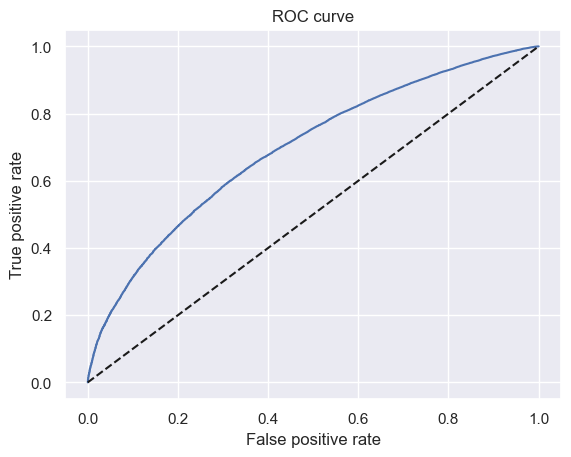

In [58]:
plt.plot(fpr, tpr)
# We plot the false positive rate along the x-axis and the true positive rate along the y-axis,
# thus plotting the ROC curve.
plt.plot(fpr, fpr, linestyle = '--', color = 'k')
# We plot a seconary diagonal line, with dashed line style and black color.
plt.xlabel('False positive rate')
# We name the x-axis "False positive rate".
plt.ylabel('True positive rate')
# We name the x-axis "True positive rate".
plt.title('ROC curve')

In [59]:
AUROC = roc_auc_score(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test_proba'])
# Calculates the Area Under the Receiver Operating Characteristic Curve (AUROC)
# from a set of actual values and their predicted probabilities.
AUROC

0.6948830769613755

### Gini and Kolmogorov-Smirnov #### 

In [60]:
df_actual_predicted_probs = df_actual_predicted_probs.sort_values('y_hat_test_proba')

In [61]:
df_actual_predicted_probs.head()

,loan_data_targets_test,y_hat_test_proba,y_hat_test
40211,0,0.444068,0
41422,0,0.444499,0
10690,0,0.489135,0
42227,0,0.491428,0
223496,1,0.493605,0


In [62]:
df_actual_predicted_probs.tail()

,loan_data_targets_test,y_hat_test_proba,y_hat_test
246553,1,0.991604,1
241533,1,0.991736,1
239228,1,0.991966,1
293709,1,0.992124,1
251159,1,0.992626,1


In [63]:
df_actual_predicted_probs = df_actual_predicted_probs.reset_index()

In [64]:
df_actual_predicted_probs.head()

,index,loan_data_targets_test,y_hat_test_proba,y_hat_test
0,40211,0,0.444068,0
1,41422,0,0.444499,0
2,10690,0,0.489135,0
3,42227,0,0.491428,0
4,223496,1,0.493605,0


In [65]:
df_actual_predicted_probs['Cumulative N Population'] = df_actual_predicted_probs.index + 1
# We calculate the cumulative number of all observations.
# We use the new index for that. Since indexing in ython starts from 0, we add 1 to each index.
df_actual_predicted_probs['Cumulative N Good'] = df_actual_predicted_probs['loan_data_targets_test'].cumsum()
# We calculate cumulative number of 'good', which is the cumulative sum of the column with actual observations.
df_actual_predicted_probs['Cumulative N Bad'] = df_actual_predicted_probs['Cumulative N Population'] - df_actual_predicted_probs['loan_data_targets_test'].cumsum()
# We calculate cumulative number of 'bad', which is
# the difference between the cumulative number of all observations and cumulative number of 'good' for each row.

In [66]:
df_actual_predicted_probs.head()

,index,loan_data_targets_test,y_hat_test_proba,y_hat_test,Cumulative N Population,Cumulative N Good,Cumulative N Bad
0,40211,0,0.444068,0,1,0,1
1,41422,0,0.444499,0,2,0,2
2,10690,0,0.489135,0,3,0,3
3,42227,0,0.491428,0,4,0,4
4,223496,1,0.493605,0,5,1,4


In [67]:
df_actual_predicted_probs['Cumulative Perc Population'] = df_actual_predicted_probs['Cumulative N Population'] / (df_actual_predicted_probs.shape[0])
# We calculate the cumulative percentage of all observations.
df_actual_predicted_probs['Cumulative Perc Good'] = df_actual_predicted_probs['Cumulative N Good'] / df_actual_predicted_probs['loan_data_targets_test'].sum()
# We calculate cumulative percentage of 'good'.
df_actual_predicted_probs['Cumulative Perc Bad'] = df_actual_predicted_probs['Cumulative N Bad'] / (df_actual_predicted_probs.shape[0] - df_actual_predicted_probs['loan_data_targets_test'].sum())
# We calculate the cumulative percentage of 'bad'.

In [68]:
df_actual_predicted_probs.head()

,index,loan_data_targets_test,y_hat_test_proba,y_hat_test,Cumulative N Population,Cumulative N Good,Cumulative N Bad,Cumulative Perc Population,Cumulative Perc Good,Cumulative Perc Bad
0,40211,0,0.444068,0,1,0,1,0.000009,0.00000,0.000079
1,41422,0,0.444499,0,2,0,2,0.000017,0.00000,0.000159
2,10690,0,0.489135,0,3,0,3,0.000026,0.00000,0.000238
3,42227,0,0.491428,0,4,0,4,0.000034,0.00000,0.000317
4,223496,1,0.493605,0,5,1,4,0.000043,0.00001,0.000317


In [69]:
df_actual_predicted_probs.tail()

,index,loan_data_targets_test,y_hat_test_proba,y_hat_test,Cumulative N Population,Cumulative N Good,Cumulative N Bad,Cumulative Perc Population,Cumulative Perc Good,Cumulative Perc Bad
116567,246553,1,0.991604,1,116568,103955,12613,0.999966,0.999962,1.0
116568,241533,1,0.991736,1,116569,103956,12613,0.999974,0.999971,1.0
116569,239228,1,0.991966,1,116570,103957,12613,0.999983,0.999981,1.0
116570,293709,1,0.992124,1,116571,103958,12613,0.999991,0.999990,1.0
116571,251159,1,0.992626,1,116572,103959,12613,1.000000,1.000000,1.0


Text(0.5, 1.0, 'Gini')

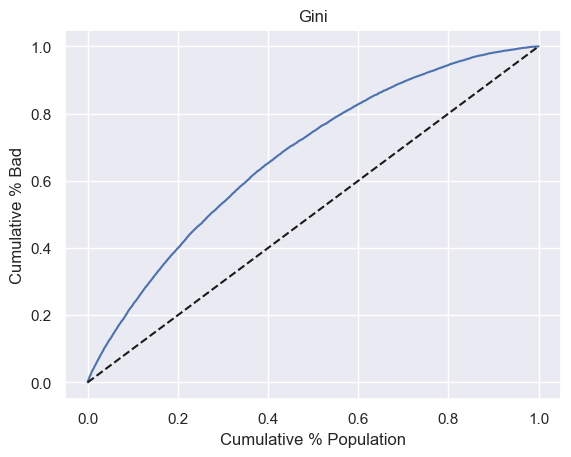

In [70]:
# Plot Gini
plt.plot(df_actual_predicted_probs['Cumulative Perc Population'], df_actual_predicted_probs['Cumulative Perc Bad'])
# We plot the cumulative percentage of all along the x-axis and the cumulative percentage 'good' along the y-axis,
# thus plotting the Gini curve.
plt.plot(df_actual_predicted_probs['Cumulative Perc Population'], df_actual_predicted_probs['Cumulative Perc Population'], linestyle = '--', color = 'k')
# We plot a seconary diagonal line, with dashed line style and black color.
plt.xlabel('Cumulative % Population')
# We name the x-axis "Cumulative % Population".
plt.ylabel('Cumulative % Bad')
# We name the y-axis "Cumulative % Bad".
plt.title('Gini')
# We name the graph "Gini".

In [71]:
Gini = AUROC * 2 - 1
Gini

0.38976615392275105

Text(0.5, 1.0, 'Kolmogorov-Smirnov')

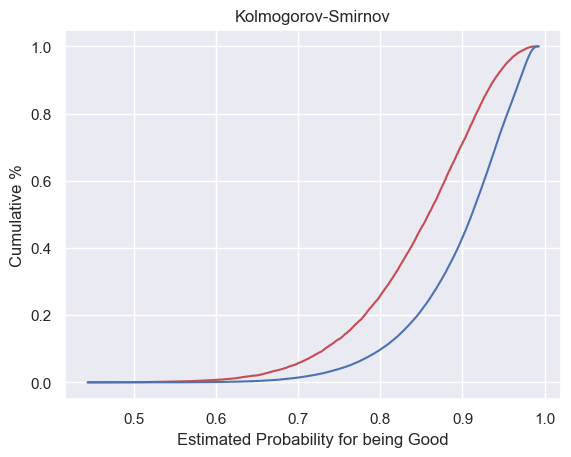

In [72]:
# Plot KS
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cumulative Perc Bad'], color = 'r')
# We plot the predicted (estimated) probabilities along the x-axis and the cumulative percentage 'bad' along the y-axis,
# colored in red.
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cumulative Perc Good'], color = 'b')
# We plot the predicted (estimated) probabilities along the x-axis and the cumulative percentage 'good' along the y-axis,
# colored in red.
plt.xlabel('Estimated Probability for being Good')
# We name the x-axis "Estimated Probability for being Good".
plt.ylabel('Cumulative %')
# We name the y-axis "Cumulative %".
plt.title('Kolmogorov-Smirnov')
# We name the graph "Kolmogorov-Smirnov".

In [73]:
KS = max(df_actual_predicted_probs['Cumulative Perc Bad'] - df_actual_predicted_probs['Cumulative Perc Good'])
# We calculate KS from the data. It is the maximum of the difference between the cumulative percentage of 'bad'
# and the cumulative percentage of 'good'.
KS

0.28452535498356296

### Applying the PD Model ###

In [74]:
inputs_test_with_ref_cat.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,home_ownership:RENT_OTHER_NONE_ANY,home_ownership:OWN,home_ownership:MORTGAGE,...,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:0-2,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>86
379472,False,False,False,False,True,False,False,0,False,True,...,0,0,1,1,0,0,0,0,0,0
221633,False,False,True,False,False,False,False,0,True,False,...,0,0,0,1,0,0,0,0,0,0
338231,False,True,False,False,False,False,False,0,False,True,...,0,1,0,1,0,0,0,0,0,0
364856,False,False,True,False,False,False,False,1,False,False,...,0,1,0,1,0,0,0,0,0,0
283061,False,False,True,False,False,False,False,0,True,False,...,1,0,0,1,0,0,0,0,0,0


In [75]:
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-0.926279,NaN
1,grade:A,1.026420,3.505111e-27
2,grade:B,0.827565,1.482560e-39
3,grade:C,0.645738,1.427020e-28
4,grade:D,0.483707,1.945033e-18
...,...,...,...
80,mths_since_last_record:3-20,0.218219,8.078998e-02
81,mths_since_last_record:21-31,0.171420,1.425902e-01
82,mths_since_last_record:32-80,0.384107,2.053436e-05
83,mths_since_last_record:81-86,0.034067,7.505150e-01


In [76]:
y_hat_test_proba

array([0.84254634, 0.84037923, 0.94192961, ..., 0.94524407, 0.68305137,
       0.79607288], shape=(116572,))

In [77]:
ref_categories

['grade:G',
 'home_ownership:RENT_OTHER_NONE_ANY',
 'addr_state:ND_NE_IA_NV_FL_HI_AL',
 'verification_status:Verified',
 'purpose:educ__sm_b__wedd__ren_en__mov__house',
 'initial_list_status:f',
 'term:60',
 'emp_length:0',
 'mths_since_issue_d:>84',
 'int_rate:>20.281',
 'mths_since_earliest_cr_line:<140',
 'inq_last_6mths:>6',
 'acc_now_delinq:0',
 'annual_inc:<20K',
 'dti:>35',
 'mths_since_last_delinq:0-3',
 'mths_since_last_record:0-2']

In [78]:
df_ref_categories = pd.DataFrame(ref_categories, columns = ['Feature name'])
df_ref_categories['Coefficients'] = 0
df_ref_categories['p_values'] = np.nan
df_ref_categories

,Feature name,Coefficients,p_values
0,grade:G,0,NaN
1,home_ownership:RENT_OTHER_NONE_ANY,0,NaN
2,addr_state:ND_NE_IA_NV_FL_HI_AL,0,NaN
3,verification_status:Verified,0,NaN
4,purpose:educ__sm_b__wedd__ren_en__mov__house,0,NaN
5,initial_list_status:f,0,NaN
6,term:60,0,NaN
7,emp_length:0,0,NaN
8,mths_since_issue_d:>84,0,NaN
9,int_rate:>20.281,0,NaN


In [79]:
df_scorecard = pd.concat([summary_table, df_ref_categories])
df_scorecard = df_scorecard.reset_index()
df_scorecard

,index,Feature name,Coefficients,p_values
0,0,Intercept,-0.926279,NaN
1,1,grade:A,1.026420,3.505111e-27
2,2,grade:B,0.827565,1.482560e-39
3,3,grade:C,0.645738,1.427020e-28
4,4,grade:D,0.483707,1.945033e-18
...,...,...,...,...
97,12,acc_now_delinq:0,0.000000,NaN
98,13,annual_inc:<20K,0.000000,NaN
99,14,dti:>35,0.000000,NaN
100,15,mths_since_last_delinq:0-3,0.000000,NaN


In [80]:
df_scorecard['Original feature name'] = df_scorecard['Feature name'].str.split(':').str[0]

In [81]:
min_score = 300
max_score = 850

In [82]:
df_scorecard.groupby('Original feature name')['Coefficients'].min()

Original feature name
Intercept                     -0.926279
acc_now_delinq                 0.000000
addr_state                     0.000000
annual_inc                    -0.050187
dti                           -0.113597
emp_length                     0.000000
grade                          0.000000
home_ownership                 0.000000
initial_list_status            0.000000
inq_last_6mths                -0.026141
int_rate                       0.000000
mths_since_earliest_cr_line    0.000000
mths_since_issue_d            -0.005253
mths_since_last_delinq         0.000000
mths_since_last_record         0.000000
purpose                        0.000000
term                           0.000000
verification_status           -0.006332
Name: Coefficients, dtype: float64

In [83]:
min_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].min().sum()
min_sum_coef

np.float64(-1.1277894818865521)

In [84]:
df_scorecard.groupby('Original feature name')['Coefficients'].max()

Original feature name
Intercept                     -0.926279
acc_now_delinq                 0.161176
addr_state                     0.446634
annual_inc                     0.599126
dti                            0.254371
emp_length                     0.135114
grade                          1.026420
home_ownership                 0.101646
initial_list_status            0.060460
inq_last_6mths                 0.309235
int_rate                       1.090072
mths_since_earliest_cr_line    0.139128
mths_since_issue_d             1.180622
mths_since_last_delinq         0.208713
mths_since_last_record         0.384107
purpose                        0.287758
term                           0.062192
verification_status            0.089790
Name: Coefficients, dtype: float64

In [85]:
max_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].max().sum()
max_sum_coef

np.float64(5.61028546776226)

In [86]:
df_scorecard['Score - Calulation'] = df_scorecard['Coefficients'] * (max_score - min_score) / (max_sum_coef - min_sum_coef)
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calulation
0,0,Intercept,-0.926279,NaN,Intercept,-75.608162
1,1,grade:A,1.026420,3.505111e-27,grade,83.782265
2,2,grade:B,0.827565,1.482560e-39,grade,67.550579
3,3,grade:C,0.645738,1.427020e-28,grade,52.708807
4,4,grade:D,0.483707,1.945033e-18,grade,39.482925
...,...,...,...,...,...,...
97,12,acc_now_delinq:0,0.000000,NaN,acc_now_delinq,0.000000
98,13,annual_inc:<20K,0.000000,NaN,annual_inc,0.000000
99,14,dti:>35,0.000000,NaN,dti,0.000000
100,15,mths_since_last_delinq:0-3,0.000000,NaN,mths_since_last_delinq,0.000000


In [87]:
# FIX: use .loc to avoid chained-indexing warning/silent fail in pandas 2.x
df_scorecard.loc[0, 'Score - Calulation'] = (
    (df_scorecard.loc[0, 'Coefficients'] - min_sum_coef) /
    (max_sum_coef - min_sum_coef)
) * (max_score - min_score) + min_score
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calulation
0,0,Intercept,-0.926279,NaN,Intercept,316.448430
1,1,grade:A,1.026420,3.505111e-27,grade,83.782265
2,2,grade:B,0.827565,1.482560e-39,grade,67.550579
3,3,grade:C,0.645738,1.427020e-28,grade,52.708807
4,4,grade:D,0.483707,1.945033e-18,grade,39.482925
...,...,...,...,...,...,...
97,12,acc_now_delinq:0,0.000000,NaN,acc_now_delinq,0.000000
98,13,annual_inc:<20K,0.000000,NaN,annual_inc,0.000000
99,14,dti:>35,0.000000,NaN,dti,0.000000
100,15,mths_since_last_delinq:0-3,0.000000,NaN,mths_since_last_delinq,0.000000


In [88]:
df_scorecard['Score - Preliminary'] = df_scorecard['Score - Calulation'].round()
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calulation,Score - Preliminary
0,0,Intercept,-0.926279,NaN,Intercept,316.448430,316.0
1,1,grade:A,1.026420,3.505111e-27,grade,83.782265,84.0
2,2,grade:B,0.827565,1.482560e-39,grade,67.550579,68.0
3,3,grade:C,0.645738,1.427020e-28,grade,52.708807,53.0
4,4,grade:D,0.483707,1.945033e-18,grade,39.482925,39.0
...,...,...,...,...,...,...,...
97,12,acc_now_delinq:0,0.000000,NaN,acc_now_delinq,0.000000,0.0
98,13,annual_inc:<20K,0.000000,NaN,annual_inc,0.000000,0.0
99,14,dti:>35,0.000000,NaN,dti,0.000000,0.0
100,15,mths_since_last_delinq:0-3,0.000000,NaN,mths_since_last_delinq,0.000000,0.0


In [89]:
min_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Preliminary'].min().sum()
min_sum_score_prel

np.float64(300.0)

In [90]:
max_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Preliminary'].max().sum()
max_sum_score_prel

np.float64(847.0)

In [91]:
df_scorecard['Difference'] = df_scorecard['Score - Preliminary'] - df_scorecard['Score - Calulation']
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calulation,Score - Preliminary,Difference
0,0,Intercept,-0.926279,NaN,Intercept,316.448430,316.0,-0.448430
1,1,grade:A,1.026420,3.505111e-27,grade,83.782265,84.0,0.217735
2,2,grade:B,0.827565,1.482560e-39,grade,67.550579,68.0,0.449421
3,3,grade:C,0.645738,1.427020e-28,grade,52.708807,53.0,0.291193
4,4,grade:D,0.483707,1.945033e-18,grade,39.482925,39.0,-0.482925
...,...,...,...,...,...,...,...,...
97,12,acc_now_delinq:0,0.000000,NaN,acc_now_delinq,0.000000,0.0,0.000000
98,13,annual_inc:<20K,0.000000,NaN,annual_inc,0.000000,0.0,0.000000
99,14,dti:>35,0.000000,NaN,dti,0.000000,0.0,0.000000
100,15,mths_since_last_delinq:0-3,0.000000,NaN,mths_since_last_delinq,0.000000,0.0,0.000000


In [92]:
df_scorecard['Score - Final'] = df_scorecard['Score - Preliminary']

# FIX: Instead of hardcoding row 77 (Udemy-specific), dynamically compute the
# adjustment needed so that min_sum + max_sum == min_score + max_score (1150).
# We apply the correction to the intercept row (index 0).
min_prel = df_scorecard.groupby('Original feature name')['Score - Preliminary'].min().sum()
max_prel = df_scorecard.groupby('Original feature name')['Score - Preliminary'].max().sum()

# How far off are we from the target range?
target_total = min_score + max_score          # 1150
current_total = min_prel + max_prel
diff = target_total - current_total

# Apply the full correction to the intercept (row 0)
df_scorecard.loc[0, 'Score - Final'] = df_scorecard.loc[0, 'Score - Preliminary'] + diff

df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calulation,Score - Preliminary,Difference,Score - Final
0,0,Intercept,-0.926279,NaN,Intercept,316.448430,316.0,-0.448430,319.0
1,1,grade:A,1.026420,3.505111e-27,grade,83.782265,84.0,0.217735,84.0
2,2,grade:B,0.827565,1.482560e-39,grade,67.550579,68.0,0.449421,68.0
3,3,grade:C,0.645738,1.427020e-28,grade,52.708807,53.0,0.291193,53.0
4,4,grade:D,0.483707,1.945033e-18,grade,39.482925,39.0,-0.482925,39.0
...,...,...,...,...,...,...,...,...,...
97,12,acc_now_delinq:0,0.000000,NaN,acc_now_delinq,0.000000,0.0,0.000000,0.0
98,13,annual_inc:<20K,0.000000,NaN,annual_inc,0.000000,0.0,0.000000,0.0
99,14,dti:>35,0.000000,NaN,dti,0.000000,0.0,0.000000,0.0
100,15,mths_since_last_delinq:0-3,0.000000,NaN,mths_since_last_delinq,0.000000,0.0,0.000000,0.0


In [93]:
min_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Final'].min().sum()

In [94]:
min_sum_score_prel

np.float64(303.0)

In [95]:
max_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Final'].max().sum()
max_sum_score_prel

np.float64(850.0)

### Calculating Credit Score #### 

In [96]:
inputs_test_with_ref_cat.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,home_ownership:RENT_OTHER_NONE_ANY,home_ownership:OWN,home_ownership:MORTGAGE,...,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:0-2,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>86
379472,False,False,False,False,True,False,False,0,False,True,...,0,0,1,1,0,0,0,0,0,0
221633,False,False,True,False,False,False,False,0,True,False,...,0,0,0,1,0,0,0,0,0,0
338231,False,True,False,False,False,False,False,0,False,True,...,0,1,0,1,0,0,0,0,0,0
364856,False,False,True,False,False,False,False,1,False,False,...,0,1,0,1,0,0,0,0,0,0
283061,False,False,True,False,False,False,False,0,True,False,...,1,0,0,1,0,0,0,0,0,0


In [97]:
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calulation,Score - Preliminary,Difference,Score - Final
0,0,Intercept,-0.926279,NaN,Intercept,316.448430,316.0,-0.448430,319.0
1,1,grade:A,1.026420,3.505111e-27,grade,83.782265,84.0,0.217735,84.0
2,2,grade:B,0.827565,1.482560e-39,grade,67.550579,68.0,0.449421,68.0
3,3,grade:C,0.645738,1.427020e-28,grade,52.708807,53.0,0.291193,53.0
4,4,grade:D,0.483707,1.945033e-18,grade,39.482925,39.0,-0.482925,39.0
...,...,...,...,...,...,...,...,...,...
97,12,acc_now_delinq:0,0.000000,NaN,acc_now_delinq,0.000000,0.0,0.000000,0.0
98,13,annual_inc:<20K,0.000000,NaN,annual_inc,0.000000,0.0,0.000000,0.0
99,14,dti:>35,0.000000,NaN,dti,0.000000,0.0,0.000000,0.0
100,15,mths_since_last_delinq:0-3,0.000000,NaN,mths_since_last_delinq,0.000000,0.0,0.000000,0.0


In [98]:
inputs_test_with_ref_cat_w_intercept = inputs_test_with_ref_cat

In [99]:
inputs_test_with_ref_cat_w_intercept.insert(0, 'Intercept', 1)

In [100]:
inputs_test_with_ref_cat_w_intercept.head()

,Intercept,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,home_ownership:RENT_OTHER_NONE_ANY,home_ownership:OWN,...,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:0-2,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>86
379472,1,False,False,False,False,True,False,False,0,False,...,0,0,1,1,0,0,0,0,0,0
221633,1,False,False,True,False,False,False,False,0,True,...,0,0,0,1,0,0,0,0,0,0
338231,1,False,True,False,False,False,False,False,0,False,...,0,1,0,1,0,0,0,0,0,0
364856,1,False,False,True,False,False,False,False,1,False,...,0,1,0,1,0,0,0,0,0,0
283061,1,False,False,True,False,False,False,False,0,True,...,1,0,0,1,0,0,0,0,0,0


In [101]:
inputs_test_with_ref_cat_w_intercept = inputs_test_with_ref_cat_w_intercept[df_scorecard['Feature name'].values]

In [102]:
inputs_test_with_ref_cat_w_intercept.head()

,Intercept,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,...,emp_length:0,mths_since_issue_d:>84,int_rate:>20.281,mths_since_earliest_cr_line:<140,inq_last_6mths:>6,acc_now_delinq:0,annual_inc:<20K,dti:>35,mths_since_last_delinq:0-3,mths_since_last_record:0-2
379472,1,False,False,False,False,True,False,False,True,0,...,0,0,0,0,0,1,0,0,0,0
221633,1,False,False,True,False,False,False,True,False,0,...,0,0,0,0,0,1,0,0,0,0
338231,1,False,True,False,False,False,False,False,True,0,...,0,0,0,0,0,1,0,0,0,0
364856,1,False,False,True,False,False,False,False,False,0,...,0,0,0,0,0,1,0,0,0,0
283061,1,False,False,True,False,False,False,True,False,0,...,0,0,0,0,0,1,0,0,0,0


In [103]:
scorecard_scores = df_scorecard['Score - Final']

In [104]:
inputs_test_with_ref_cat_w_intercept.shape

(116572, 102)

In [105]:
scorecard_scores.shape

(102,)

In [106]:
scorecard_scores = scorecard_scores.values.reshape(102, 1)

In [107]:
scorecard_scores.shape

(102, 1)

In [108]:
y_scores = inputs_test_with_ref_cat_w_intercept.dot(scorecard_scores)
y_scores.head()

,0
379472,531.0
221633,530.0
338231,621.0
364856,588.0
283061,643.0


In [109]:
sum_coef_from_score = ((y_scores - min_score) / (max_score - min_score)) * (max_sum_coef - min_sum_coef) + min_sum_coef

In [111]:
sum_coef_from_score = sum_coef_from_score.astype(float)
y_hat_proba_from_score = np.exp(sum_coef_from_score) / (np.exp(sum_coef_from_score) + 1)
y_hat_proba_from_score.head()

,0
379472,0.845822
221633,0.844218
338231,0.942934
364856,0.916866
283061,0.955821


In [112]:
y_hat_test_proba[0: 5]

array([0.84254634, 0.84037923, 0.94192961, 0.91654542, 0.9551711 ])

In [113]:
df_actual_predicted_probs['y_hat_test_proba'].head()

0    0.444068
1    0.444499
2    0.489135
3    0.491428
4    0.493605
Name: y_hat_test_proba, dtype: float64

### Setting Cut-offs ### 

In [ ]:
tr = 0.9
df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > tr, 1, 0)

In [115]:
pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted'])

Predicted,0,1
Actual,,
0,8973,3640
1,44806,59153


In [116]:
pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]

Predicted,0,1
Actual,,
0,0.076974,0.031225
1,0.384363,0.507437


In [117]:
(pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[0, 0] + (pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[1, 1]

np.float64(0.5844113509247504)

In [118]:
roc_curve(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test_proba'])

(array([0.        , 0.        , 0.        , ..., 0.99968287, 0.99968287,
        1.        ], shape=(21521,)),
 array([0.00000000e+00, 9.61917679e-06, 7.69534143e-05, ...,
        9.99990381e-01, 1.00000000e+00, 1.00000000e+00], shape=(21521,)),
 array([       inf, 0.99262641, 0.99132267, ..., 0.49443425, 0.49360484,
        0.44406848], shape=(21521,)))

In [119]:
fpr, tpr, thresholds = roc_curve(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test_proba'])

Text(0.5, 1.0, 'ROC curve')

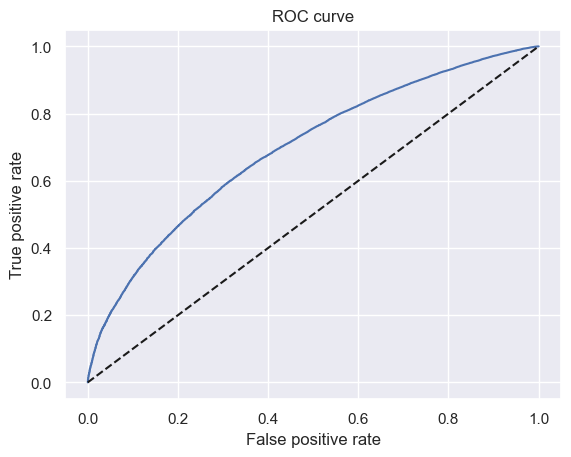

In [120]:
plt.plot(fpr, tpr)
plt.plot(fpr, fpr, linestyle = '--', color = 'k')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')

In [121]:
thresholds

array([       inf, 0.99262641, 0.99132267, ..., 0.49443425, 0.49360484,
       0.44406848], shape=(21521,))

In [122]:
thresholds.shape

(21521,)

In [123]:
df_cutoffs = pd.concat([pd.DataFrame(thresholds), pd.DataFrame(fpr), pd.DataFrame(tpr)], axis = 1)

In [124]:
df_cutoffs.columns = ['thresholds', 'fpr', 'tpr']

In [125]:
df_cutoffs.head()

,thresholds,fpr,tpr
0,inf,0.000000,0.000000
1,0.992626,0.000000,0.000010
2,0.991323,0.000000,0.000077
3,0.991187,0.000079,0.000077
4,0.989707,0.000079,0.000606


In [126]:
df_cutoffs['thresholds'][0] = 1 - 1/ np.power(10, 16)

/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_67852/3335375656.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_cutoffs['thresholds'][0] = 1 - 1/ np.power(10, 16)


In [127]:
df_cutoffs['Score'] = ((np.log(df_cutoffs['thresholds'] / (1 - df_cutoffs['thresholds'])) - min_sum_coef) * ((max_score - min_score) / (max_sum_coef - min_sum_coef)) + min_score).round()

In [129]:
df_cutoffs.head()

,thresholds,fpr,tpr,Score
0,1.000000,0.000000,0.000000,3391.0
1,0.992626,0.000000,0.000010,792.0
2,0.991323,0.000000,0.000077,779.0
3,0.991187,0.000079,0.000077,778.0
4,0.989707,0.000079,0.000606,765.0


In [130]:
df_cutoffs['Score'][0] = max_score

/var/folders/59/mg36zpzn3fqbx4_xccrmb89m0000gn/T/ipykernel_67852/3137964156.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_cutoffs['Score'][0] = max_score


In [131]:
df_cutoffs.head()

,thresholds,fpr,tpr,Score
0,1.000000,0.000000,0.000000,850.0
1,0.992626,0.000000,0.000010,792.0
2,0.991323,0.000000,0.000077,779.0
3,0.991187,0.000079,0.000077,778.0
4,0.989707,0.000079,0.000606,765.0


In [132]:
df_cutoffs.tail()

,thresholds,fpr,tpr,Score
21516,0.498557,0.999524,0.999981,392.0
21517,0.497017,0.999524,0.999990,391.0
21518,0.494434,0.999683,0.999990,390.0
21519,0.493605,0.999683,1.000000,390.0
21520,0.444068,1.000000,1.000000,374.0


In [133]:
def n_approved(p):
    return np.where(df_actual_predicted_probs['y_hat_test_proba'] >= p, 1, 0).sum()

In [134]:
df_cutoffs['N Approved'] = df_cutoffs['thresholds'].apply(n_approved)
# Assuming that all credit applications above a given probability of being 'good' will be approved,
# when we apply the 'n_approved' function to a threshold, it will return the number of approved applications.
# Thus, here we calculate the number of approved appliations for al thresholds.
df_cutoffs['N Rejected'] = df_actual_predicted_probs['y_hat_test_proba'].shape[0] - df_cutoffs['N Approved']
# Then, we calculate the number of rejected applications for each threshold.
# It is the difference between the total number of applications and the approved applications for that threshold.
df_cutoffs['Approval Rate'] = df_cutoffs['N Approved'] / df_actual_predicted_probs['y_hat_test_proba'].shape[0]
# Approval rate equalts the ratio of the approved applications and all applications.
df_cutoffs['Rejection Rate'] = 1 - df_cutoffs['Approval Rate']

In [135]:
df_cutoffs.head()

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
0,1.000000,0.000000,0.000000,850.0,0,116572,0.000000,1.000000
1,0.992626,0.000000,0.000010,792.0,1,116571,0.000009,0.999991
2,0.991323,0.000000,0.000077,779.0,8,116564,0.000069,0.999931
3,0.991187,0.000079,0.000077,778.0,9,116563,0.000077,0.999923
4,0.989707,0.000079,0.000606,765.0,64,116508,0.000549,0.999451


In [136]:
df_cutoffs.tail()

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
21516,0.498557,0.999524,0.999981,392.0,116564,8,0.999931,0.000069
21517,0.497017,0.999524,0.999990,391.0,116565,7,0.999940,0.000060
21518,0.494434,0.999683,0.999990,390.0,116567,5,0.999957,0.000043
21519,0.493605,0.999683,1.000000,390.0,116568,4,0.999966,0.000034
21520,0.444068,1.000000,1.000000,374.0,116572,0,1.000000,0.000000


In [137]:
df_cutoffs.iloc[5000: 6200,]

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
5000,0.915591,0.206692,0.473292,587.0,51810,64762,0.444446,0.555554
5001,0.915575,0.206692,0.473437,587.0,51825,64747,0.444575,0.555425
5002,0.915569,0.206771,0.473437,587.0,51826,64746,0.444584,0.555416
5003,0.915544,0.206771,0.473571,587.0,51840,64732,0.444704,0.555296
5004,0.915543,0.206850,0.473571,587.0,51841,64731,0.444712,0.555288
...,...,...,...,...,...,...,...,...
6195,0.905858,0.258463,0.534740,577.0,58851,57721,0.504847,0.495153
6196,0.905853,0.258463,0.534788,577.0,58856,57716,0.504890,0.495110
6197,0.905853,0.258543,0.534788,577.0,58857,57715,0.504898,0.495102
6198,0.905848,0.258543,0.534894,577.0,58868,57704,0.504993,0.495007


In [139]:
df_cutoffs.iloc[1000: 2000, ]

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
1000,0.958600,0.038532,0.173953,649.0,18570,98002,0.159301,0.840699
1001,0.958582,0.038532,0.174069,649.0,18582,97990,0.159404,0.840596
1002,0.958581,0.038611,0.174069,649.0,18583,97989,0.159412,0.840588
1003,0.958430,0.038611,0.174982,648.0,18678,97894,0.160227,0.839773
1004,0.958429,0.038690,0.174982,648.0,18679,97893,0.160236,0.839764
...,...,...,...,...,...,...,...,...
1995,0.944422,0.079204,0.269597,623.0,29026,87546,0.248996,0.751004
1996,0.944420,0.079283,0.269597,623.0,29027,87545,0.249005,0.750995
1997,0.944403,0.079283,0.269741,623.0,29042,87530,0.249134,0.750866
1998,0.944403,0.079363,0.269741,623.0,29043,87529,0.249142,0.750858


In [140]:
inputs_train_with_ref_cat.to_csv("../data/processed/inputs_train_with_ref_cat.csv")

In [141]:
df_scorecard.to_csv("../data/processed/df_scorecard.csv")